In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Моменты распределений

# Математическое ожидание

Зачастую **математическое ожидание** можно соотнести со **средним взвешенным**.

Рассмотрим пример.

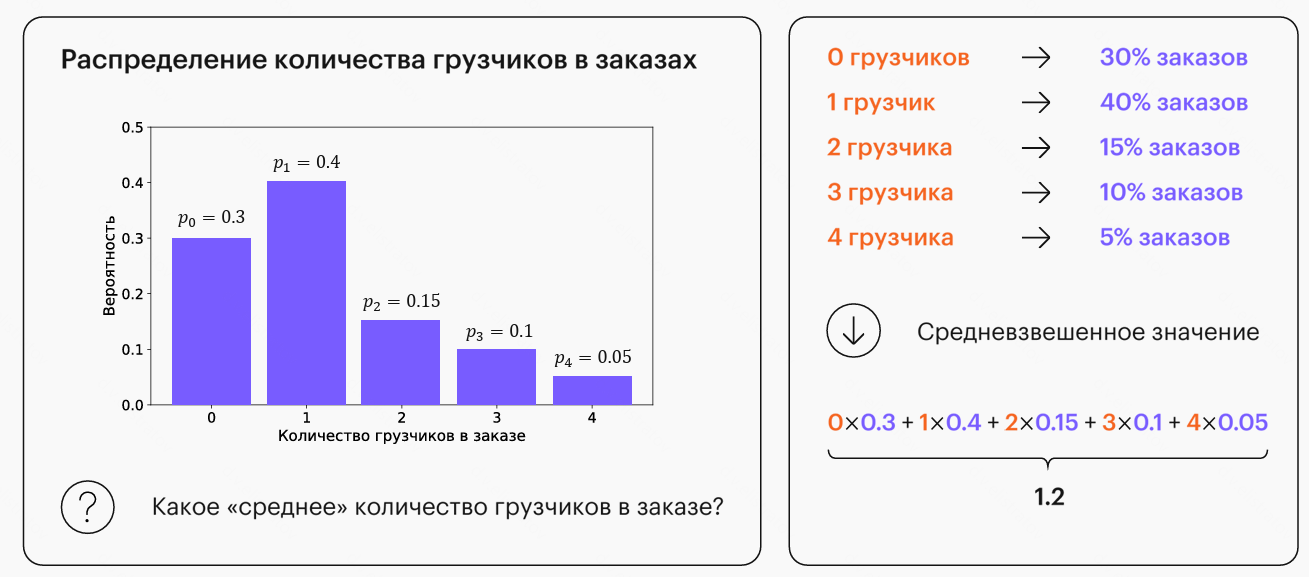

**Рассмотрим две методики расчёта математического ожидания для дискретных и непрерывных случайных величин**

## Матожидание дискретных распределений

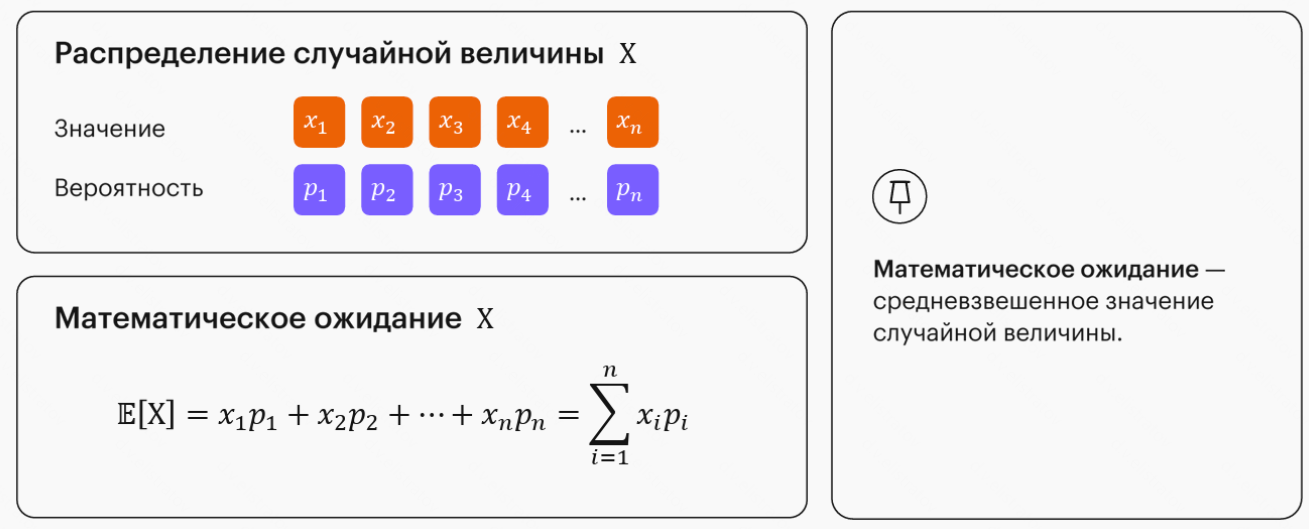

### Пример 1. Матожидание Бернулли

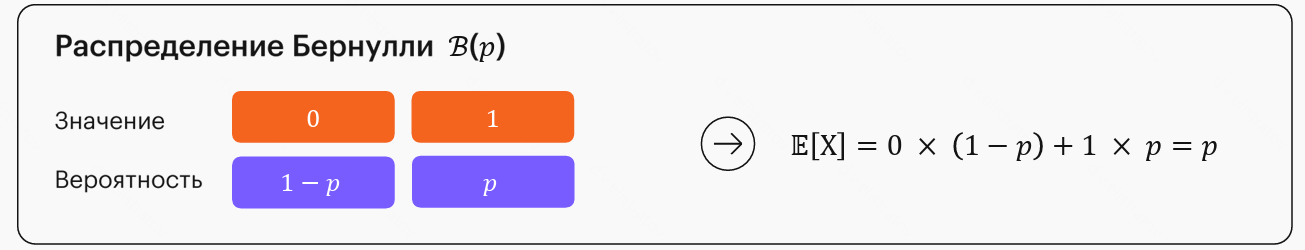

### Пример 2. Матожидание броска кубика

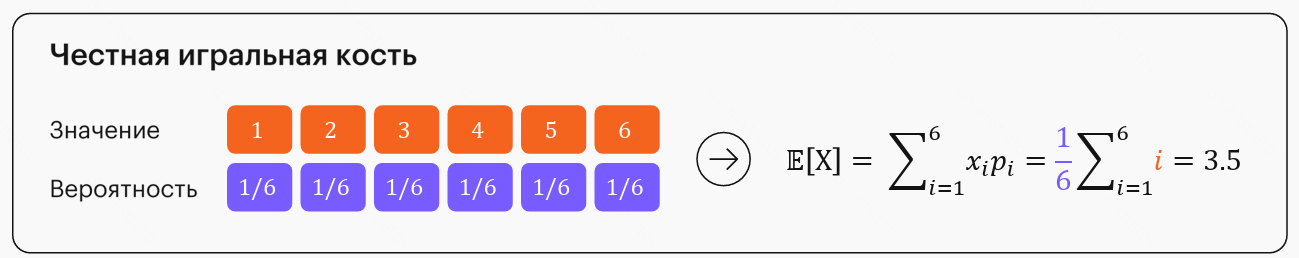

## Матожидание непрерывных распределений

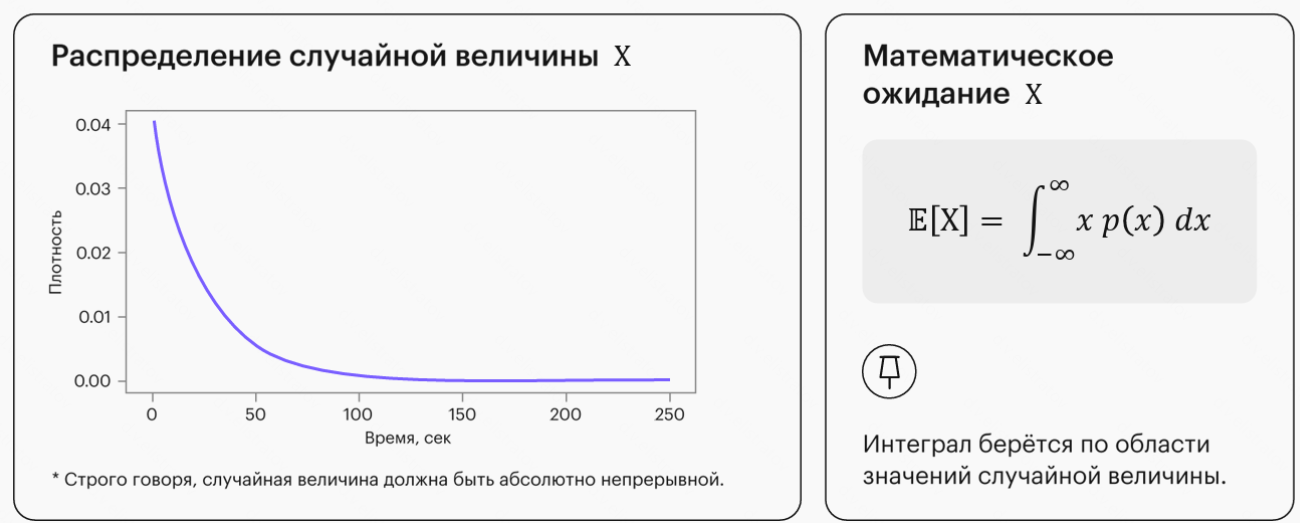

## Саммари

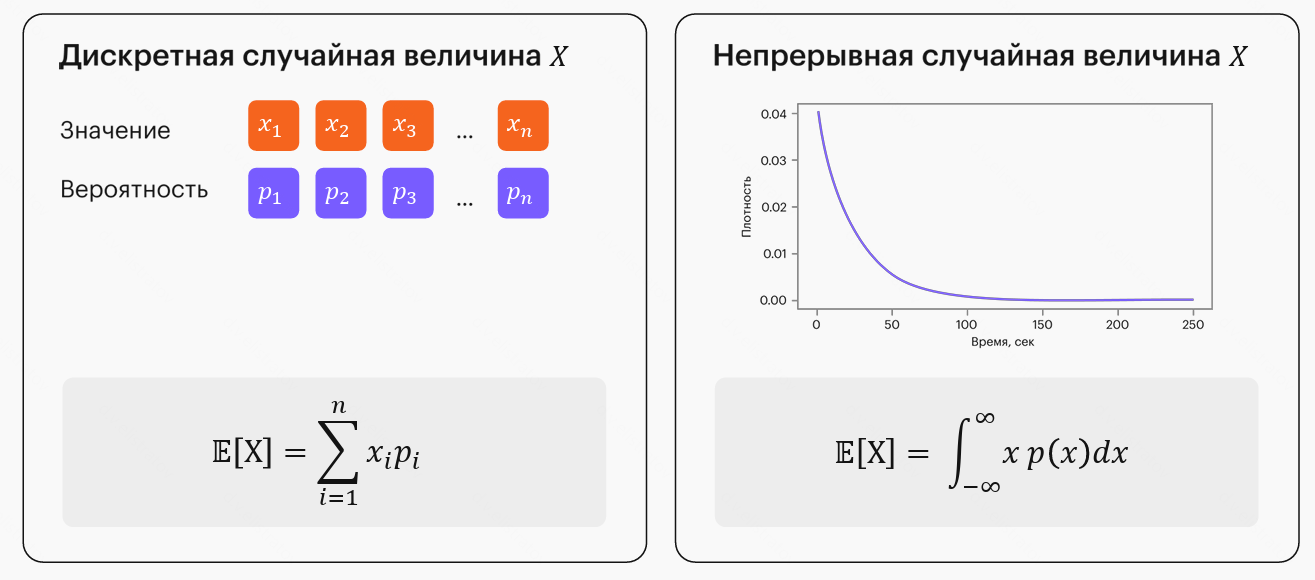

## Свойства матожидания

### Свойство 1. Линейность

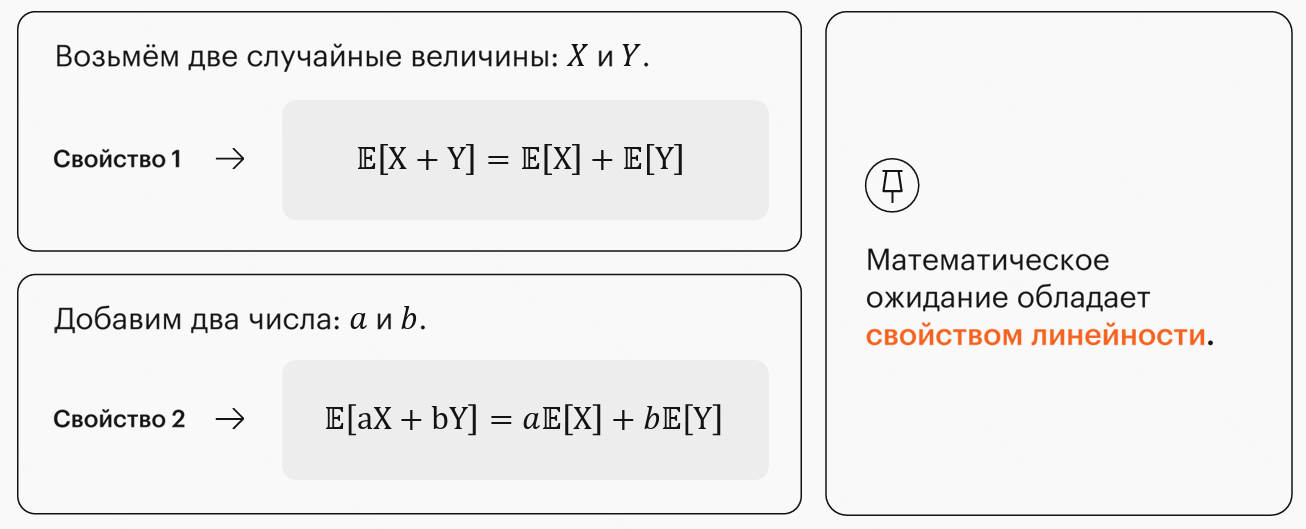

#### Пример. Матожидание линейной комбинации

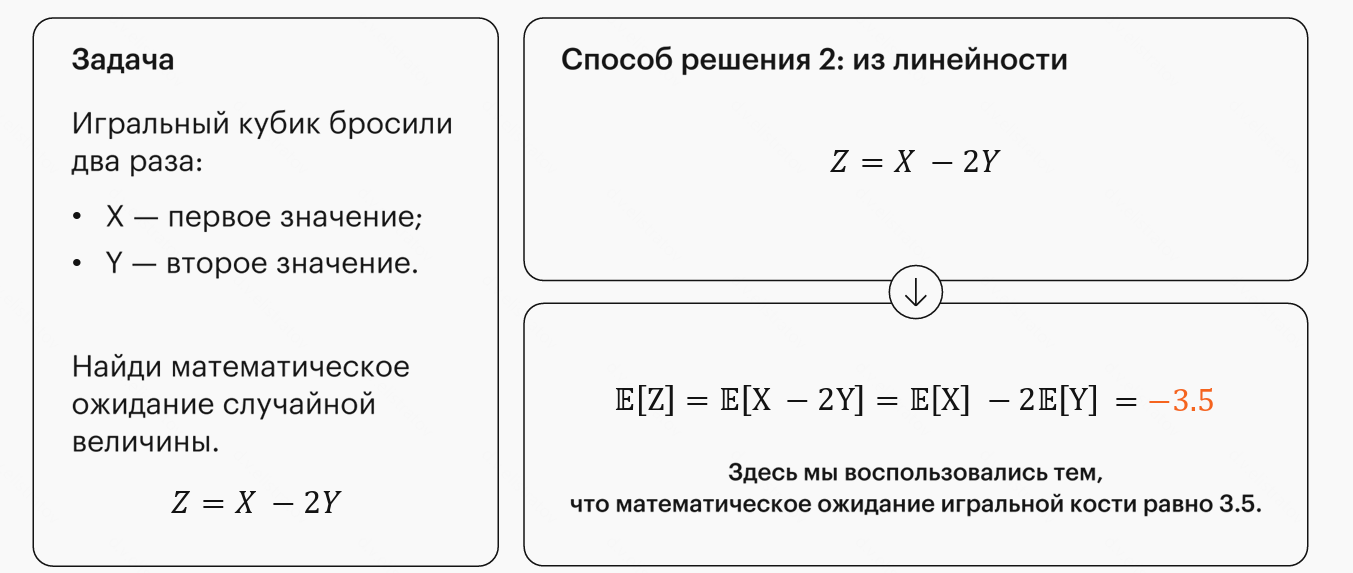

### Свойство 2. Матожидание от функции случайной величины

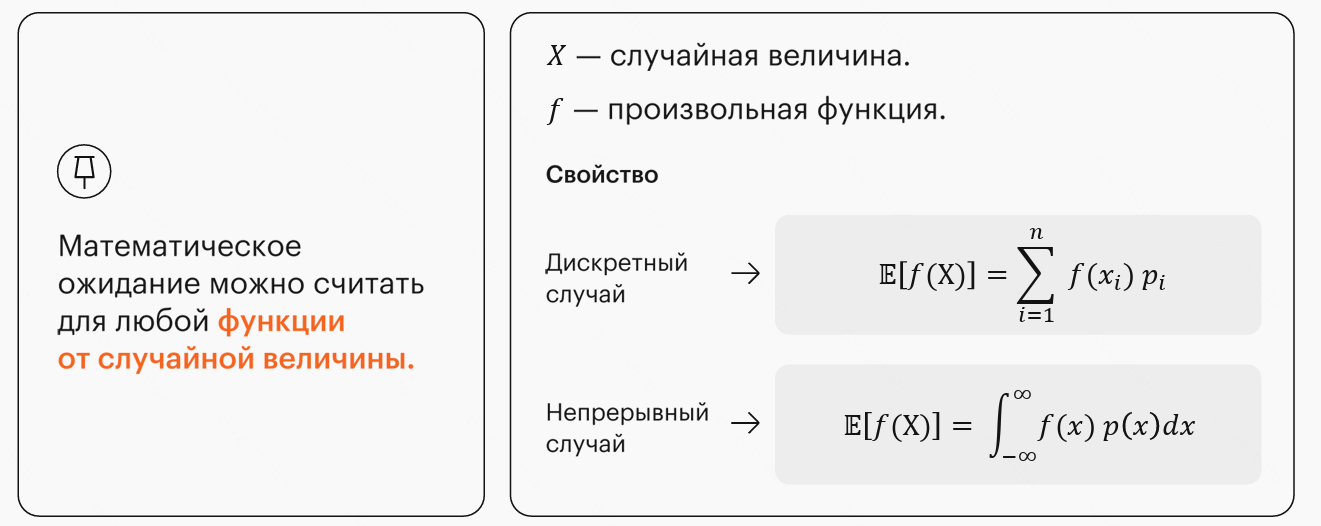

#### Пример. Матожидание экспоненты от равномерного распределения

Рассмотрим случайную величину $$Y = e^X, X \sim U[a, b]$$


Тогда по формуле получаем:

$$
\mathbb{E}[Y] = \mathbb{E}[e^X] = \int_{a}^{b} e^x \cdot \frac{1}{b-a}  dx = \frac{1}{b-a} (e^b - e^a)
$$

### Свойство 3. Матожидание произведения независимых случайных величин

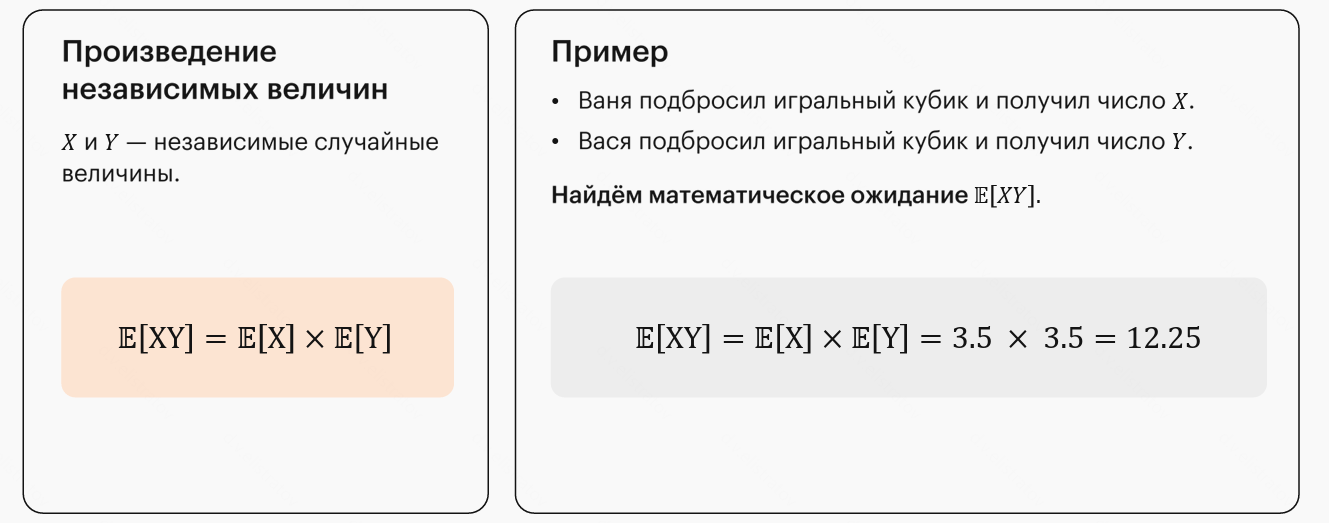

#### Контрпример. Произведение матожидания зависимых случайных величин

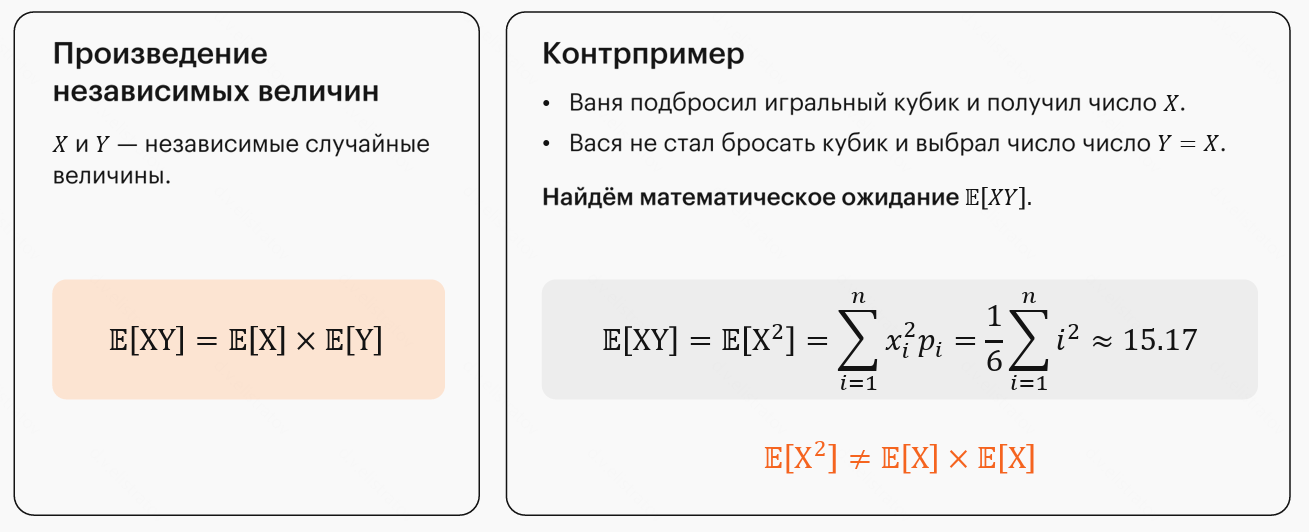

# Функция выживания и матожидание


**Функция выживания**:

$$S(x)=1-F(x)=\mathbb{P}(X>x)$$

где

$$
F(x)=\mathbb{P}(X\le x)
$$

— функция распределения CDF. $\mathbb{P}$

Случайная величина $X$ принимает только неотрицательные целые значения.


**Утверждение**

Докажем, что матожидание $\mathbb{E}[X]$ можно вычислить по функции выживания $S$:

$$\mathbb{E}[X]=\sum_{k=0}^{\infty}S(k)$$

То есть

$$\mathbb{E}[X]=\sum_{k=0}^{\infty}\mathbb{P}(X>k)$$

**Доказательство**

Так как $X$ принимает только неотрицательные целые значения,

$$\mathbb{E}[X]=\sum_{n=0}^{\infty} n\mathbb{P}(X=n)$$

Представим число $n$ как сумму единиц:

$$n=\sum_{k=1}^{n}1$$

Тогда

$$
\begin{aligned}
\mathbb{E}[X]=\sum_{n=0}^{\infty} n\mathbb{P}(X=n)=\sum_{n=0}^{\infty}\left(\sum_{k=1}^{n}1\right)\mathbb{P}(X=n)=\sum_{k=1}^{\infty}\sum_{n=k}^{\infty}\mathbb{P}(X=n)=\sum_{k=1}^{\infty}\mathbb{P}(X\ge k)
\end{aligned}
$$

Поскольку $X$ принимает целые значения,

$$\mathbb{P}(X\ge k)=\mathbb{P}(X>k-1)$$

Значит,

$$\sum_{k=1}^{\infty}\mathbb{P}(X\ge k)=\sum_{k=1}^{\infty}\mathbb{P}(X>k-1)$$

Сделаем замену индекса $j=k-1$:

$$\sum_{k=1}^{\infty}\mathbb{P}(X>k-1)=\sum_{j=0}^{\infty}\mathbb{P}(X>j)$$

Следовательно,

$$\mathbb{E}[X]=\sum_{j=0}^{\infty}\mathbb{P}(X>j)=\sum_{j=0}^{\infty}S(j)$$



**Вывод**

Матожидание - это:
 - Сумма всех значений функции выживания в дискретном случае;
 - Интеграл функции выживания в непрерывном случае;

## Пример дискретного случая

**Задача**

Пусть случайная величина $X$ принимает значения $0, 1, 2, 3$ со следующими вероятностями:

| $x$ | $0$ | $1$ | $2$ | $3$ |
|---|---:|---:|---:|---:|
| $\mathbb{P}(X=x)$ | 0.1 | 0.2 | 0.3 | 0.4 |

Сравним два способа вычисления матожидания.

По определению:

$$
\mathbb{E}[X]=\sum_x x\mathbb{P}(X=x)
$$

Через функцию выживания:

$$
\mathbb{E}[X]=\sum_{k=0}^{\infty}S(k)
$$

где

$$
S(k)=\mathbb{P}(X>k)
$$

Поскольку $X$ не может быть больше $3$, начиная с $k=3$ функция выживания равна нулю. Поэтому достаточно вычислить $S(0)$, $S(1)$ и $S(2)$.

Запустите код ниже и сравните матожидание, вычисленное по определению, с суммой значений функции выживания.

Должно получиться:

$$
S(0)=0.9,\qquad S(1)=0.7,\qquad S(2)=0.4
$$

поэтому

$$
\mathbb{E}[X]
=
S(0)+S(1)+S(2)
=
0.9+0.7+0.4
=
2
$$

Оба способа дают одинаковый результат.

В дискретном случае матожидание неотрицательной целочисленной случайной величины можно получить как сумму значений функции выживания.

In [ ]:
x = np.array([0, 1, 2, 3])
p = np.array([0.1, 0.2, 0.3, 0.4])

# Матожидание по определению
expected_value = np.sum(x * p)

# Значения функции выживания S(k) = P(X > k)
survival = np.array([
    p[x > k].sum()
    for k in x
])

expected_from_survival = survival.sum()

print("E[X] по определению:", expected_value)
print("S(k):", survival)
print("E[X] через S(k):", expected_from_survival)

E[X] по определению: 2.0
S(k): [0.9 0.7 0.4 0. ]
E[X] через S(k): 2.0


## Пример непрерывного случая

Пусть неотрицательная случайная величина $X$ принимает значения от $0$ до $1$ и имеет плотность

$$
f(x)=2x,\qquad 0\le x\le1
$$

Найдём функцию распределения:

$$
F(x)
=
\int_0^x 2t\,dt
=
x^2
$$

Тогда функция выживания равна

$$
S(x)
=
1-F(x)
=
1-x^2
$$

Сравним два способа вычисления матожидания.

По определению:

$$
\mathbb{E}[X]
=
\int_0^1 x f(x)\,dx
$$

Через функцию выживания:

$$
\mathbb{E}[X]
=
\int_0^1 S(x)\,dx
$$

Запустите код ниже и сравните результаты двух вычислений.

В обоих случаях должно получиться:

$$
\mathbb{E}[X]=\frac{2}{3}
$$

Во втором способе мы вычисляем площадь под графиком функции выживания.

Поскольку в этом примере $X$ принимает значения только от $0$ до $1$, при $x>1$ имеем $S(x)=0$. Поэтому

$$
\mathbb{E}[X]
=
\int_0^\infty S(x)\,dx
=
\int_0^1 S(x)\,dx
$$

Таким образом, в непрерывном случае матожидание неотрицательной случайной величины можно интерпретировать как площадь под функцией выживания.

In [ ]:
x = np.linspace(0, 1, 100_000)

# Плотность
f = 2 * x

# Функция выживания
survival = 1 - x**2

# Матожидание по определению
expected_value = np.trapezoid(x * f, x)

# Матожидание как площадь под функцией выживания
expected_from_survival = np.trapezoid(survival, x)

print("E[X] по определению:", expected_value)
print("E[X] через S(x):", expected_from_survival)

E[X] по определению: 0.6666666667000006
E[X] через S(x): 0.6666666666499997


# Дисперсия

Дисперсия - это **мера разброса** случайной величины.

Рассмотрим на примере с приборами.

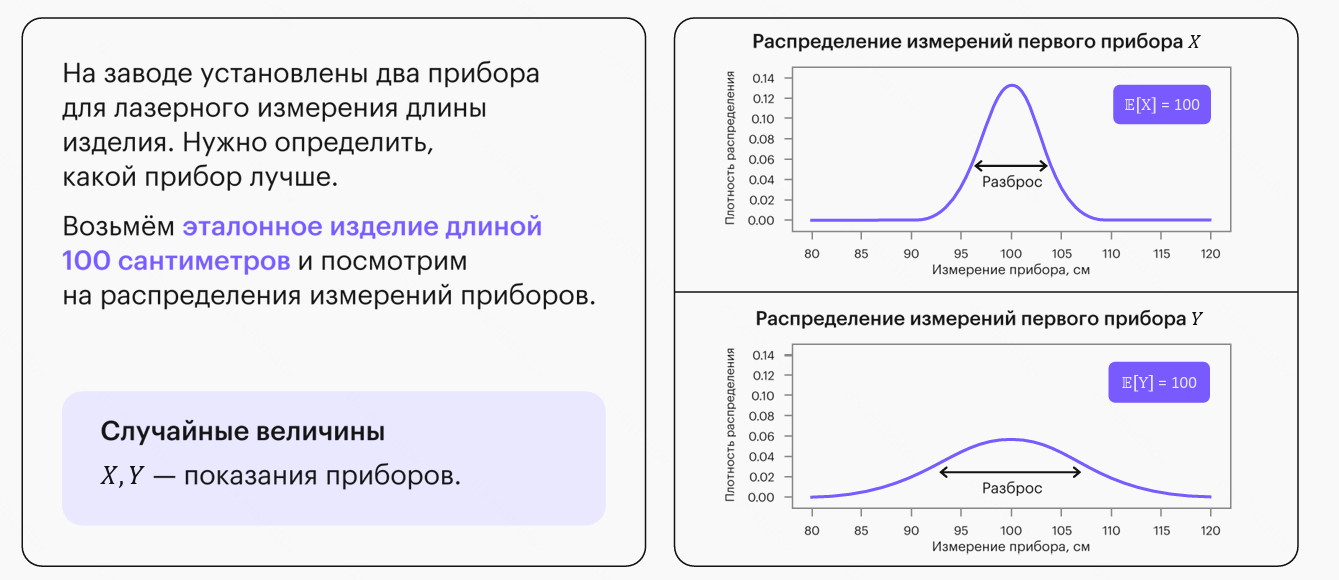

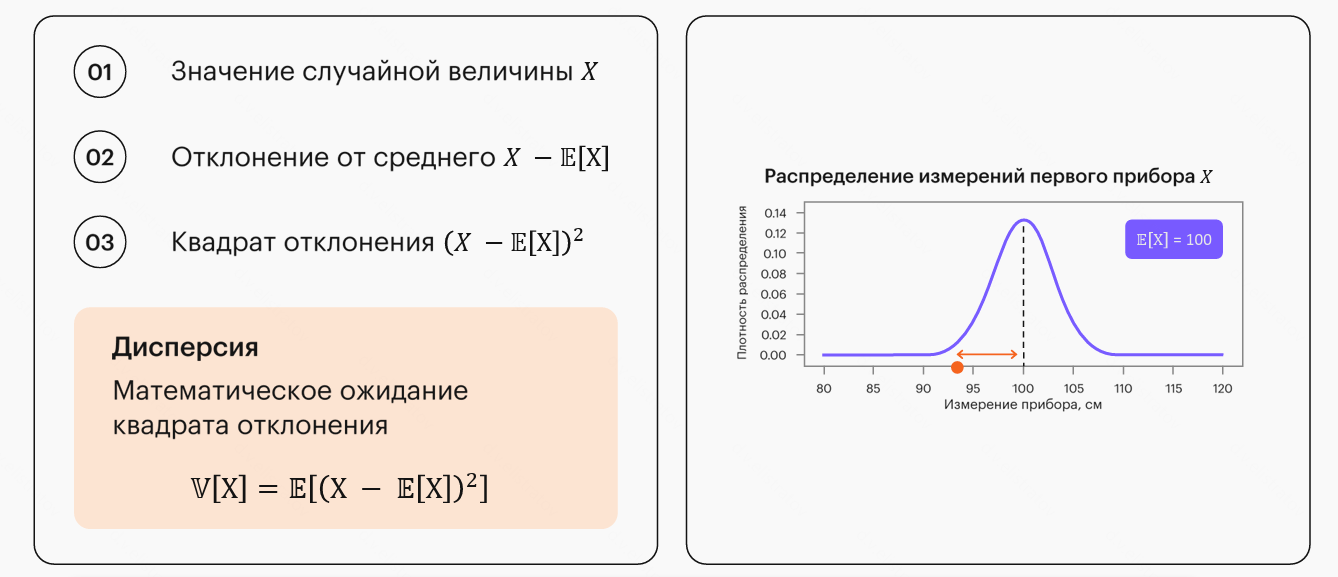

По аналогии с **математическим ожиданием**,
*дисперсия* также бывает в дискретной и непрерывной вариации.

## Дисперсия дискретного распределения

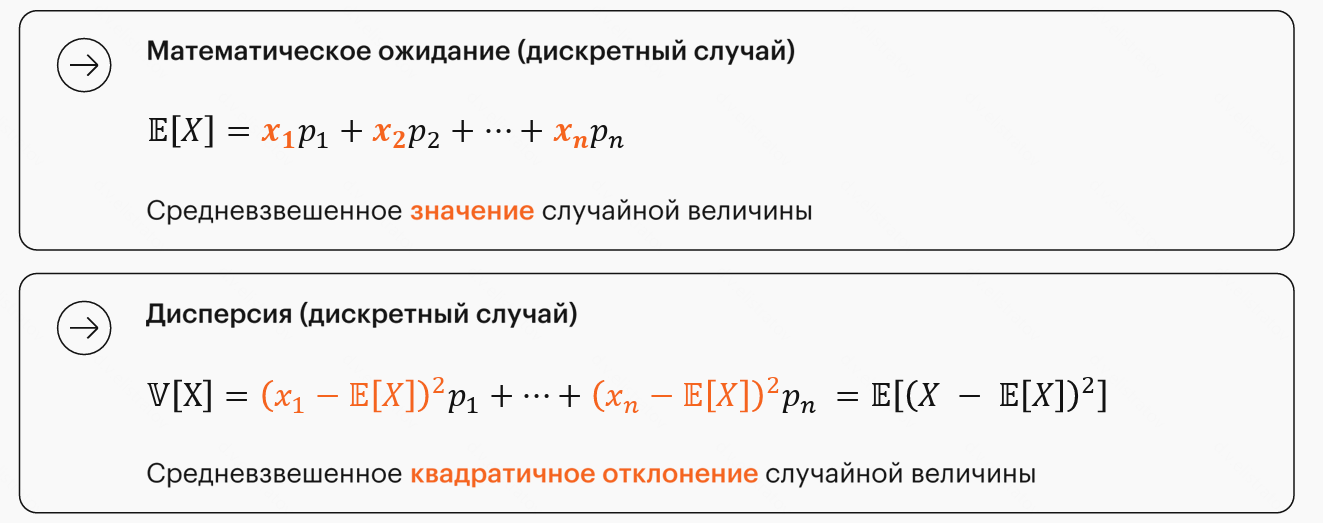

## Дисперсия непрерывного распределения

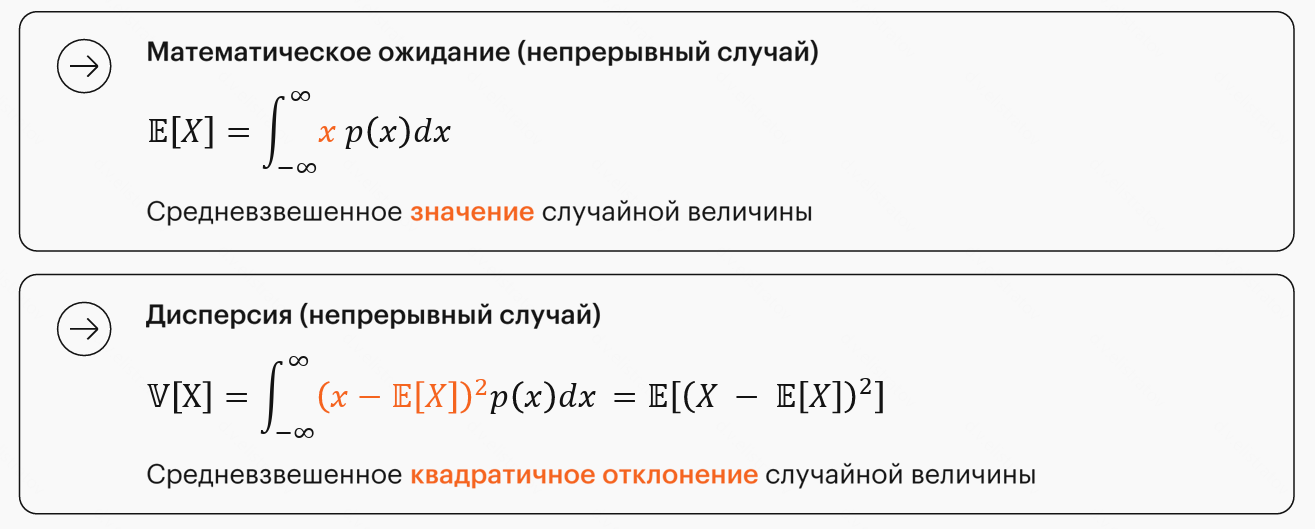

### Пример. Дисперсия непрерывного равномерного распределения

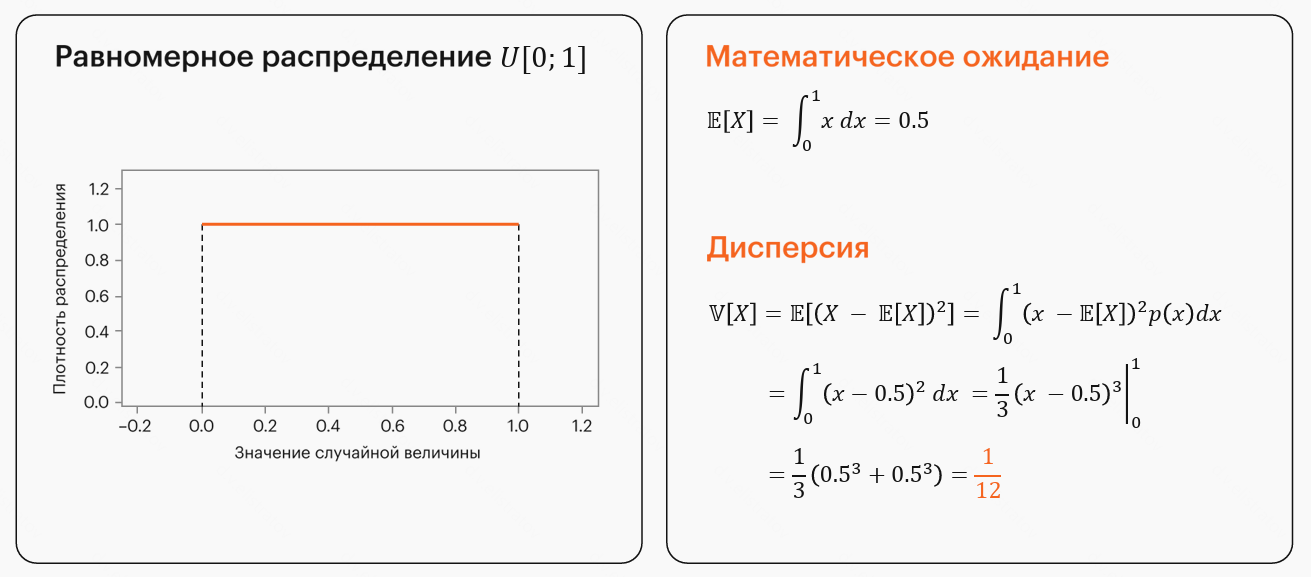

## Стандартное отклонение

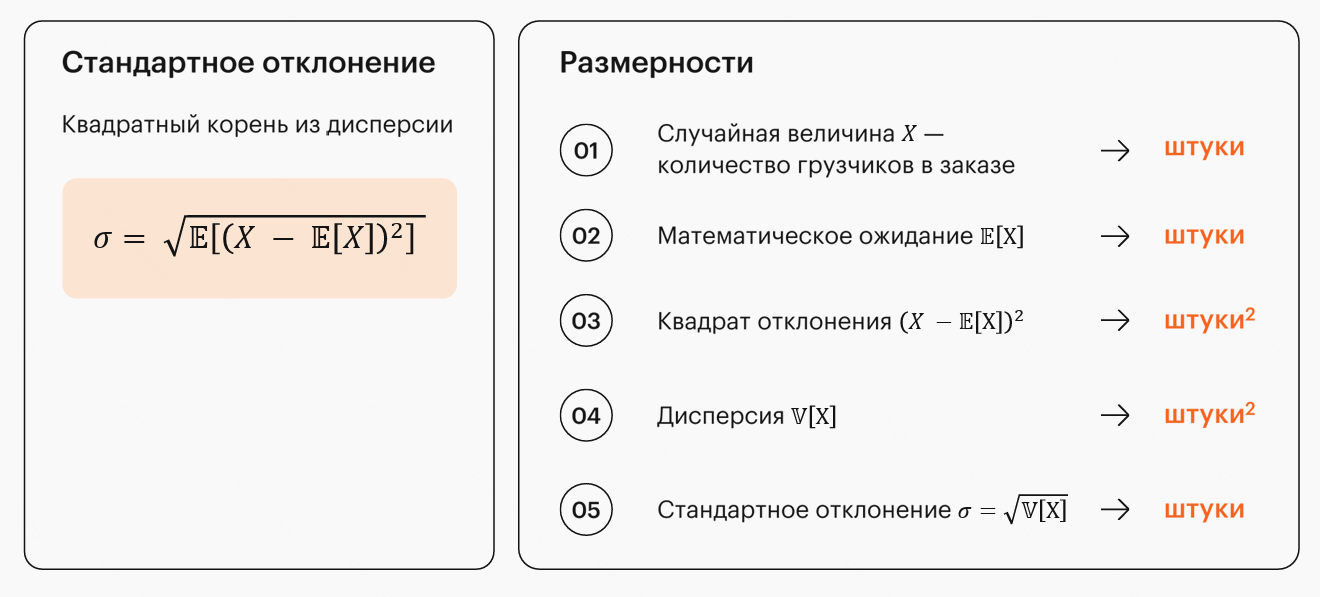

## Свойства дисперсии

### Свойство 1. Упрощённая формула расчёта

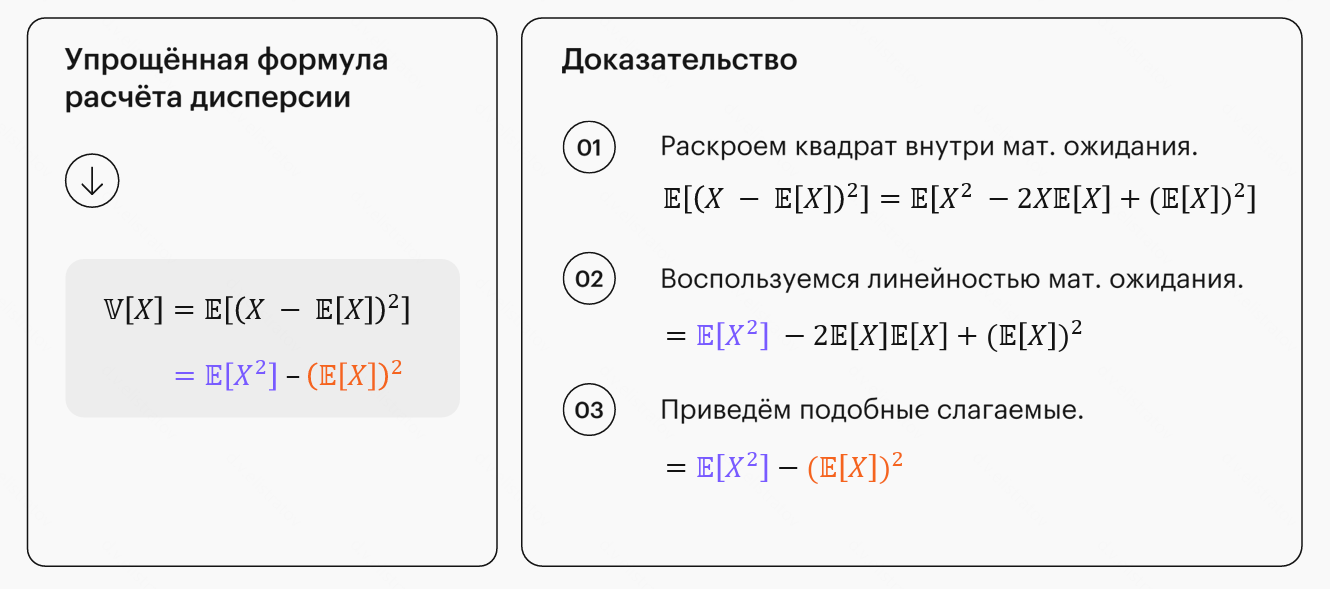

#### Пример. Дисперсия непрерывного равномерного распределения

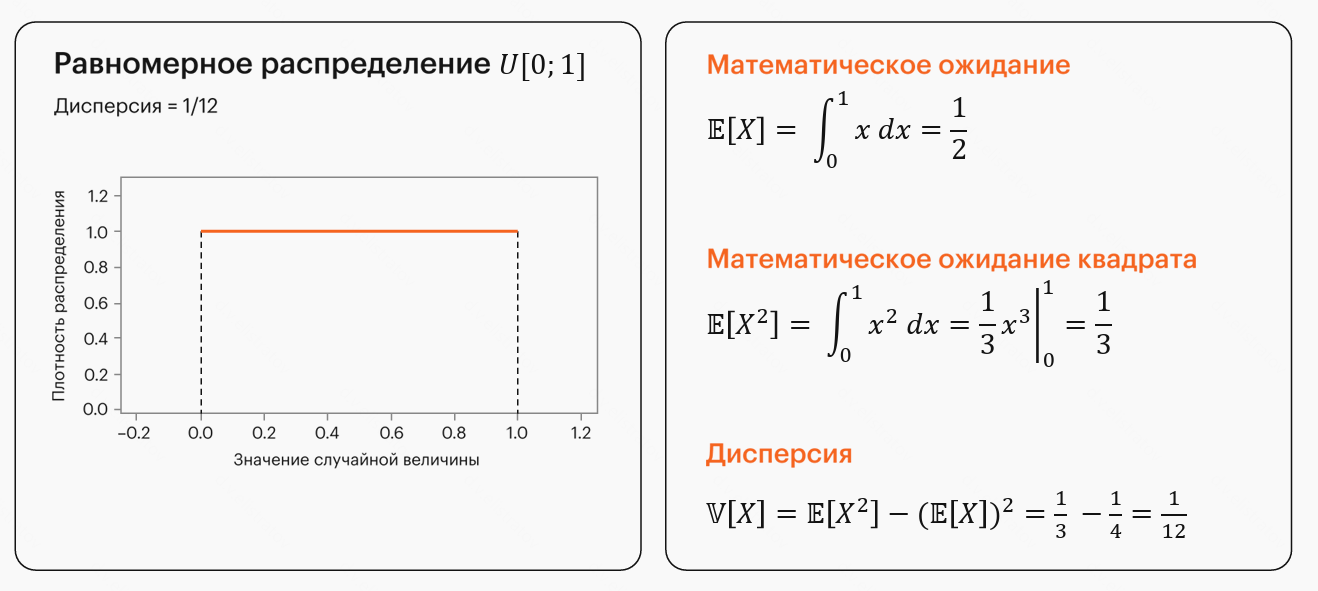

### Свойство 2. Умножение дисперсии на константу и сумма дисперсий

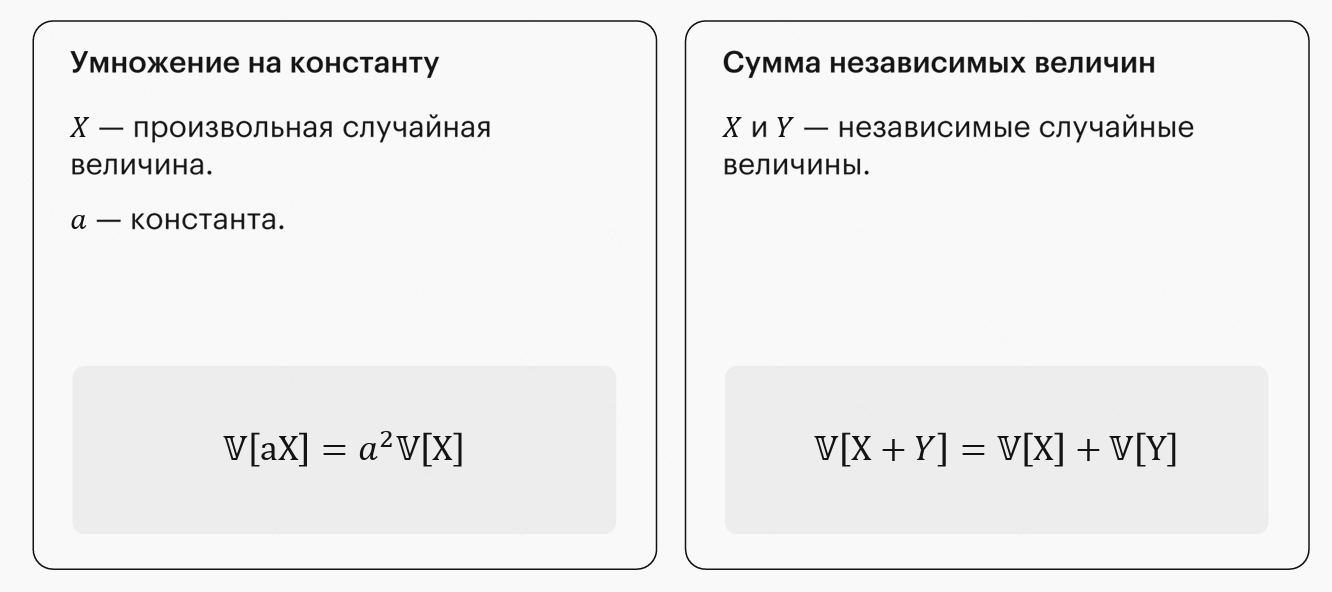

#### Пример 1. Дисперсия линейной комбинации

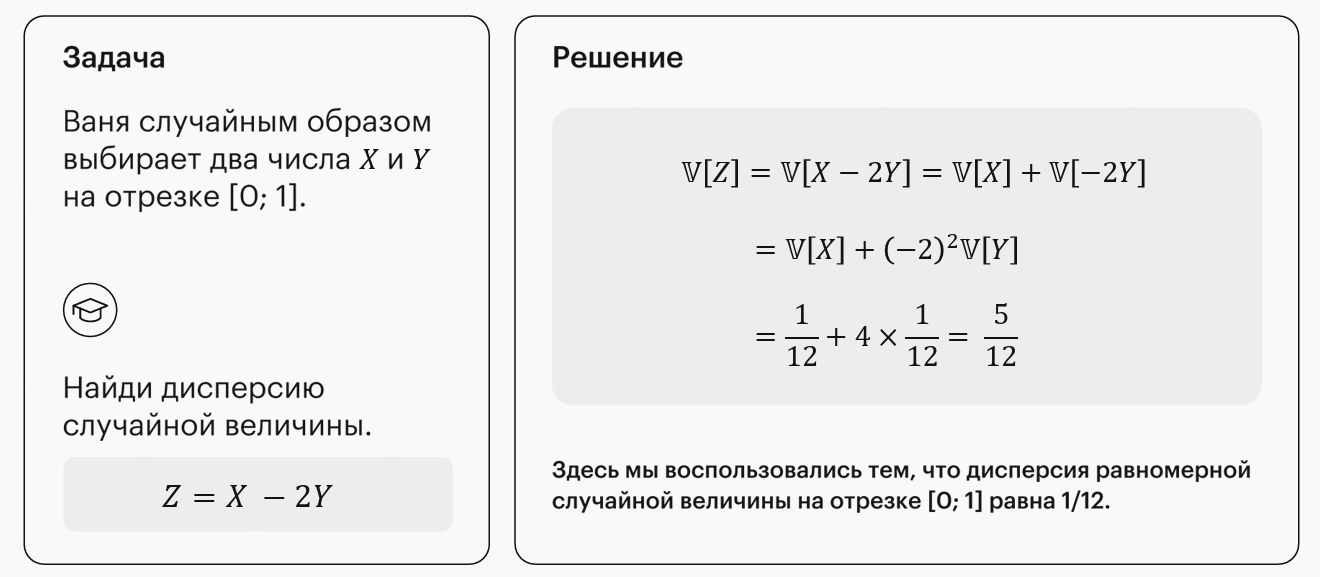

#### Контрпример 1. Дисперсия линейной комбинации зависимых случайных величин

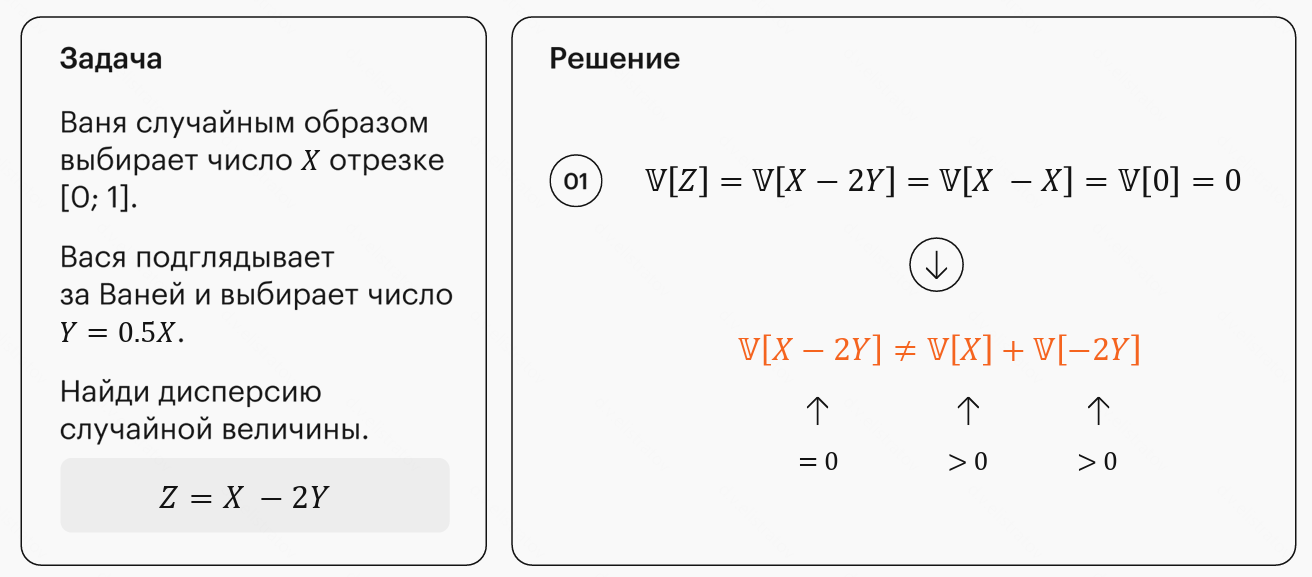

#### Пример 2. Дисперсия среднего распределений

**Дисперсия**

$$\text{Var}(\bar{X}) = \text{Var}\left(\frac{1}{n} \sum_{i=1}^n X_i\right) = \frac{1}{n^2} \text{Var}\left(\sum_{i=1}^n X_i\right)$$

Поскольку величины **независимы**:
$$\text{Var}\left(\sum_{i=1}^n X_i\right) = \sum_{i=1}^n \text{Var}(X_i) = \sum_{i=1}^n \sigma^2 = n\sigma^2$$

**Следовательно:**

$$\text{Var}(\bar{X}) = \frac{1}{n^2} \cdot n\sigma^2 = \frac{\sigma^2}{n}$$

# Другие параметры распределений

## Медиана

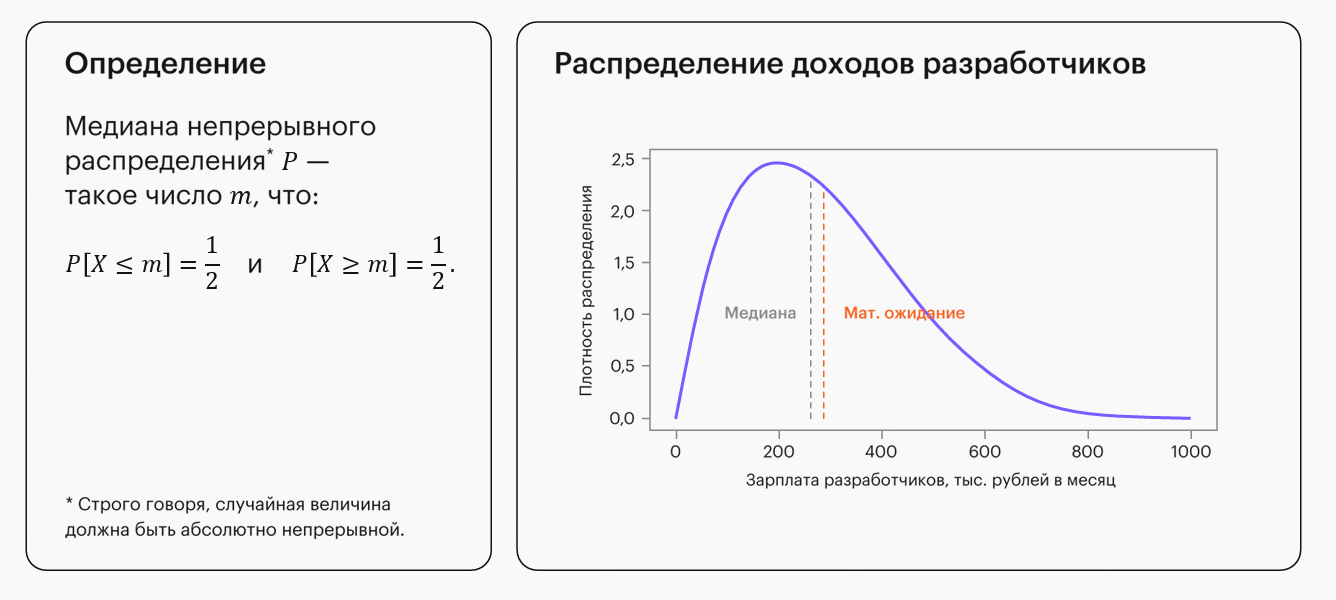

## Асимметрия

### Третий центральный момент

$$\mu_3=\mathbb E[(X-\mathbb E[X])^3]$$

Пусть

$$
\mu=\mathbb E[X]
$$

Тогда третий центральный момент:

$$
\mu_3=\mathbb E[(X-\mu)^3]=\mathbb E[X^3-3\mu X^2+3\mu^2X-\mu^3]=\mathbb E[X^3]-3\mu\mathbb E[X^2]+3\mu^2\mathbb E[X]-\mu^3
$$

Так как $\mu=\mathbb E[X]$, получаем:

$$
\mu_3=\mathbb E[X^3]-3\mathbb E[X]\mathbb E[X^2]+3(\mathbb E[X])^3-(\mathbb E[X])^3=\mathbb E[X^3]-3\mathbb E[X]\mathbb E[X^2]+2(\mathbb E[X])^3
$$

---

### Асимметрия

$$\operatorname{Skew}(X)=\frac{\mu_3}{\sigma^3}$$

Интерпретация:
- $\operatorname{Skew}(X)>0$ — длинный правый хвост;
- $\operatorname{Skew}(X)<0$ — длинный левый хвост;
- $\operatorname{Skew}(X)\approx0$ — распределение близко к симметричному.

---

**Вывод**

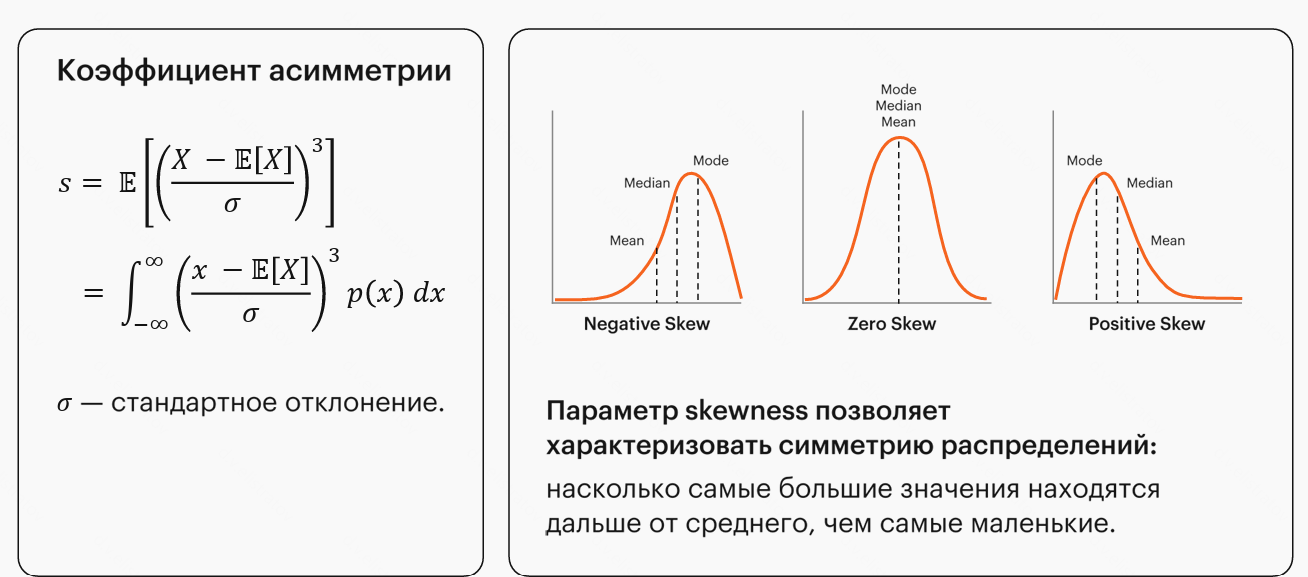

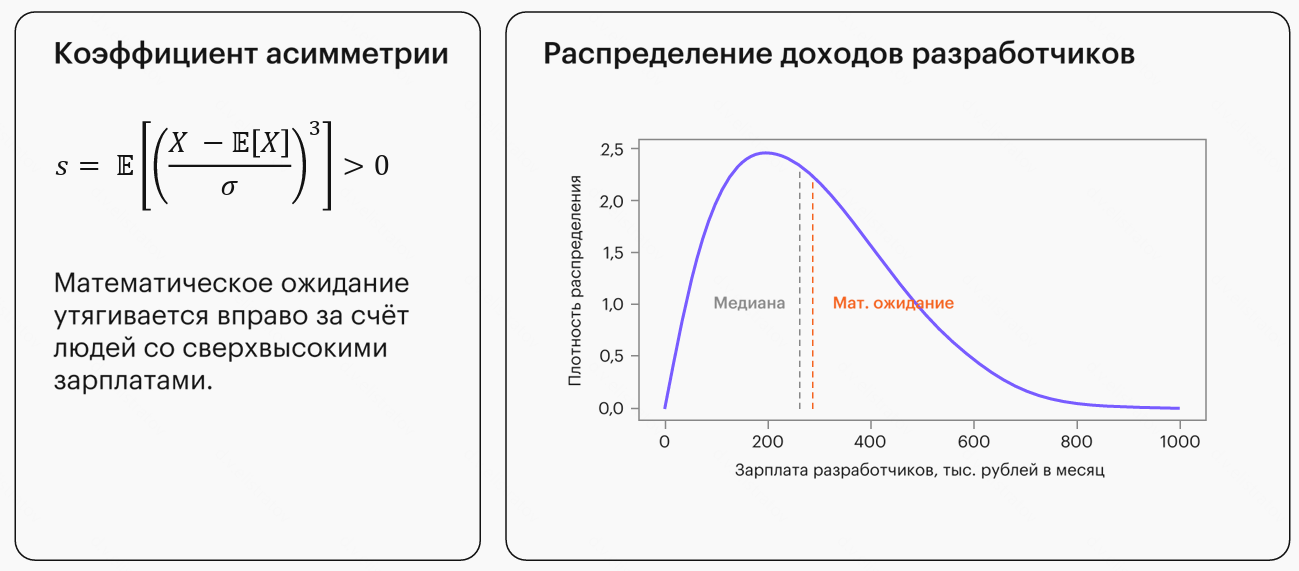

## Эксцесс

### Четвёртый центральный момент

$$
\mu_4=\mathbb E[(X-\mathbb E[X])^4]
$$

$$\mu_4=\mathbb E[(X-\mu)^4]=\mathbb E[X^4-4\mu X^3+6\mu^2X^2-4\mu^3X+\mu^4]=\mathbb E[X^4]-4\mu\mathbb E[X^3]+6\mu^2\mathbb E[X^2]-4\mu^3\mathbb E[X]+\mu^4$$

Так как $\mu=\mathbb E[X]$, получаем:

$$
\mu_4=\mathbb E[X^4]-4\mathbb E[X]\mathbb E[X^3]+6(\mathbb E[X])^2\mathbb E[X^2]-4(\mathbb E[X])^4+(\mathbb E[X])^4=\mathbb E[X^4]-4\mathbb E[X]\mathbb E[X^3]+6(\mathbb E[X])^2\mathbb E[X^2]-3(\mathbb E[X])^4
$$

---

### Куртозис и эксцесс

Куртозис:
$$\operatorname{Kurt}(X)=\frac{\mu_4}{\sigma^4}$$

Эксцесс:
$$\operatorname{Ex}(X)=\operatorname{Kurt}(X)-3$$

Интерпретация:
- $\operatorname{Ex}(X)>0$ — более тяжёлые хвосты и более острая вершина по сравнению с нормальным распределением;
- $\operatorname{Ex}(X)<0$ — более лёгкие хвосты и более плоская вершина;
- $\operatorname{Ex}(X)=0$ — форма близка к нормальному распределению.

**Вывод**

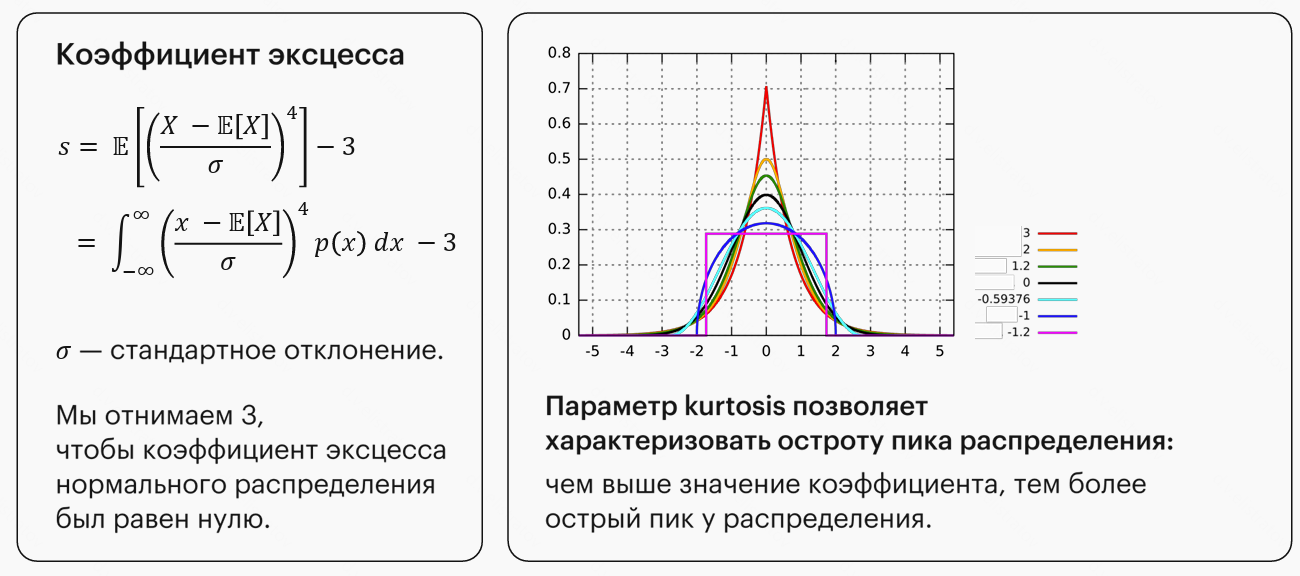

**Что же такое нормальное распределение, мы узнаем позже**

# Неравенство Маркова

Пусть $X$ — неотрицательная случайная величина:

$$
X \geq 0.
$$

Тогда для любого $\varepsilon > 0$

$$
\mathbb{P}(X \geq \varepsilon)
\leq
\frac{\mathbb{E}[X]}{\varepsilon}.
$$

Неравенство Маркова даёт верхнюю оценку вероятности того, что случайная величина примет большое значение.

**Интуитивно**:

Если среднее значение $\mathbb{E}[X]$ невелико, то случайная величина не может слишком часто принимать значения, существенно превосходящие это среднее.

## Пример экспоненциального распределения

Пусть

$$
X \sim \operatorname{Exp}(1).
$$

Случайная величина $X$ неотрицательна, а её математическое ожидание равно

$$
\mathbb{E}[X]=1.
$$

Возьмём

$$
\varepsilon=2.
$$

По неравенству Маркова

$$
\mathbb{P}(X \geq 2)
\leq
\frac{\mathbb{E}[X]}{2}
=
\frac{1}{2}
=
0.5.
$$

Для экспоненциального распределения с параметром $1$ точная вероятность равна

$$
\mathbb{P}(X \geq 2)
=
e^{-2}
\approx
0.1353.
$$

Таким образом,

$$
\mathbb{P}(X \geq 2)
\approx
0.1353
\leq
0.5.
$$

Неравенство Маркова выполняется, но даёт достаточно грубую верхнюю оценку точной вероятности.

## Вывод неравенства Чебышёва из неравенства Маркова

Пусть случайная величина $X$ имеет конечные математическое ожидание и дисперсию.

Рассмотрим неотрицательную случайную величину

$$
Y = \left(X-\mathbb{E}[X]\right)^2.
$$

По неравенству Маркова для любого $\varepsilon > 0$

$$
\mathbb{P}\left(Y \geq \varepsilon^2\right)
\leq
\frac{\mathbb{E}[Y]}{\varepsilon^2}.
$$

Подставим определение $Y$:

$$
\mathbb{P}\left(\left(X-\mathbb{E}[X]\right)^2 \geq \varepsilon^2\right)
\leq
\frac{\mathbb{E}\left[\left(X-\mathbb{E}[X]\right)^2\right]}{\varepsilon^2}.
$$

События

$$
\left(X-\mathbb{E}[X]\right)^2 \geq \varepsilon^2
$$

и

$$
\left|X-\mathbb{E}[X]\right| \geq \varepsilon
$$

совпадают. Кроме того,

$$
\mathbb{E}\left[\left(X-\mathbb{E}[X]\right)^2\right]
=
\operatorname{Var}(X).
$$

Следовательно,

$$
\mathbb{P}\left(\left|X-\mathbb{E}[X]\right| \geq \varepsilon\right)
\leq
\frac{\operatorname{Var}(X)}{\varepsilon^2}.
$$

Это и есть неравенство Чебышёва.

# Неравенство Чебышёва


Если у случайной величины $X$ существует дисперсия, то для любого $\varepsilon > 0$

$$\mathbb{P}(|X-\mathbb{E}(X)|>\varepsilon)\leqslant \frac{\operatorname{Var}(X)}{\varepsilon ^2}$$



**Интуитивно:**

Вероятность отклониться от матожидания больше чем на какую-то величину контролируется мерой разброса распределения.

## Пример нормального стандартного распределения

Пусть

$$
X \sim \mathcal{N}(0,1).
$$

Тогда

$$
\mathbb{E}[X] = 0
$$

и

$$
\operatorname{Var}(X) = 1.
$$

По неравенству Чебышёва для любого $\varepsilon > 0$

$$
\mathbb{P}\left(|X - \mathbb{E}[X]| \geq \varepsilon\right)
\leq
\frac{\operatorname{Var}(X)}{\varepsilon^2}.
$$

Для стандартной нормальной случайной величины получаем

$$
\mathbb{P}(|X| \geq \varepsilon)
\leq
\frac{1}{\varepsilon^2}.
$$

Возьмём $\varepsilon = 2$. Тогда

$$
\mathbb{P}(|X| \geq 2)
\leq
\frac{1}{2^2}
=
\frac{1}{4}
=
0.25.
$$

Точное значение вероятности равно

$$
\mathbb{P}(|X| \geq 2)
=
2\left(1-\Phi(2)\right)
\approx
0.0455.
$$

Таким образом,

$$
\mathbb{P}(|X| \geq 2)
\approx
0.0455
\leq
0.25.
$$

## Пример нормального не стандартного распределения

Пусть

$$
X \sim \mathcal{N}(\mu,\sigma^2).
$$

Тогда

$$
\mathbb{E}[X] = \mu
$$

и

$$
\operatorname{Var}(X) = \sigma^2.
$$

По неравенству Чебышёва для любого $\varepsilon > 0$

$$
\mathbb{P}\left(|X-\mathbb{E}[X]| \geq \varepsilon\right)
\leq
\frac{\operatorname{Var}(X)}{\varepsilon^2}.
$$

Для нормальной случайной величины получаем

$$
\mathbb{P}\left(|X-\mu| \geq \varepsilon\right)
\leq
\frac{\sigma^2}{\varepsilon^2}.
$$

Рассмотрим случай

$$
X \sim \mathcal{N}(5,4).
$$

Тогда

$$
\mu = 5
$$

и

$$
\sigma^2 = 4.
$$

Возьмём $\varepsilon = 4$. По неравенству Чебышёва

$$
\mathbb{P}\left(|X-5| \geq 4\right)
\leq
\frac{4}{4^2}
=
\frac{1}{4}
=
0.25.
$$

Поскольку $\sigma = 2$, точную вероятность можно найти с помощью стандартизации:

$$
\mathbb{P}\left(|X-5| \geq 4\right)
=
\mathbb{P}\left(\left|\frac{X-5}{2}\right| \geq 2\right).
$$

Следовательно,

$$
\mathbb{P}\left(|X-5| \geq 4\right)
=
2\left(1-\Phi(2)\right)
\approx
0.0455.
$$

Таким образом,

$$
\mathbb{P}\left(|X-5| \geq 4\right)
\approx
0.0455
\leq
0.25.
$$

**Неравенство Чебышёва выполняется, но даёт довольно грубую верхнюю оценку точной вероятности.**

## Переход от случайной величины к среднему значению

Однако более важной для нас вариацией является формула с заменой $X$ на $\overline{X}_n$:

$$\mathbb{P}(|\overline{X}_n-\mathbb{E}(X)|>\varepsilon)\leqslant \frac{\mathbb{D}(\overline{X}_n)}{\varepsilon ^2}.$$

$$\mathbb{P}(|\overline{X}_n-\mathbb{E}(X)|>\varepsilon)\leqslant \frac{\mathbb{D}(X)}{n \varepsilon ^2}.$$

Таким образом, видим, что при бесконечном $n$ **мажоранта** стремится к нулю, а значит, и разница между средним и матожиданием стремится к нулю.

# Оценки моментов на выборке

## Свойство состоятельности

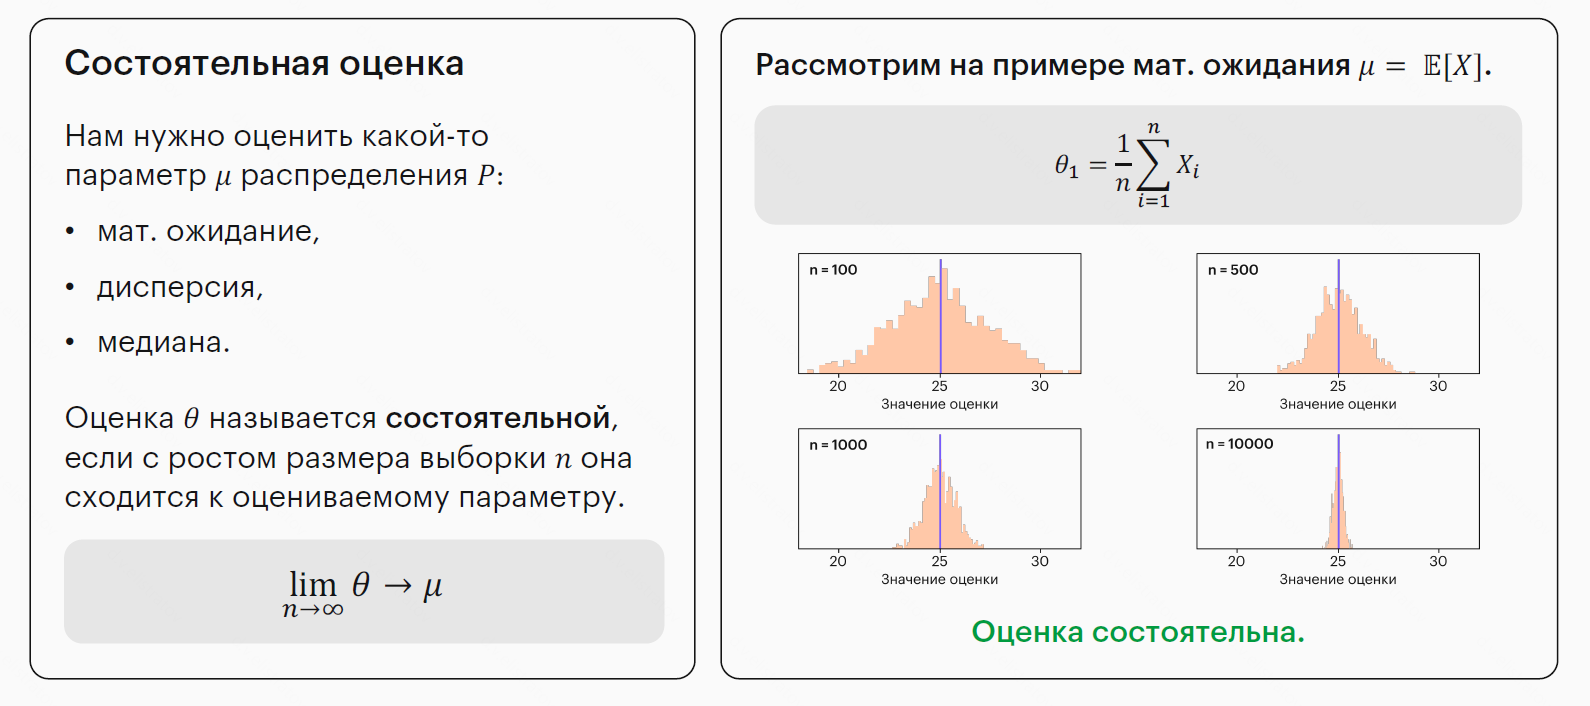

# Закон больших чисел

**Формулировка**

Пусть $X_1, \dotsc, X_n$, попарно независимые и одинаково распределенные случайные величины с конечной дисперсией $\text{Var}(X_m) < \infty$

Тогда:

$$\frac{X_1 + \dotsc + X_n}{n} \overset{P}{\longrightarrow} \mathbb{E}(X)$$

А также:

$$P\left\{\left| \frac{X_1 + \dotsc + X_n}{n} - \mathbb{E}(X) \right| \ge \varepsilon\right\} \to 0, \text{при } n\to  \infty \text{ и } \varepsilon > 0$$


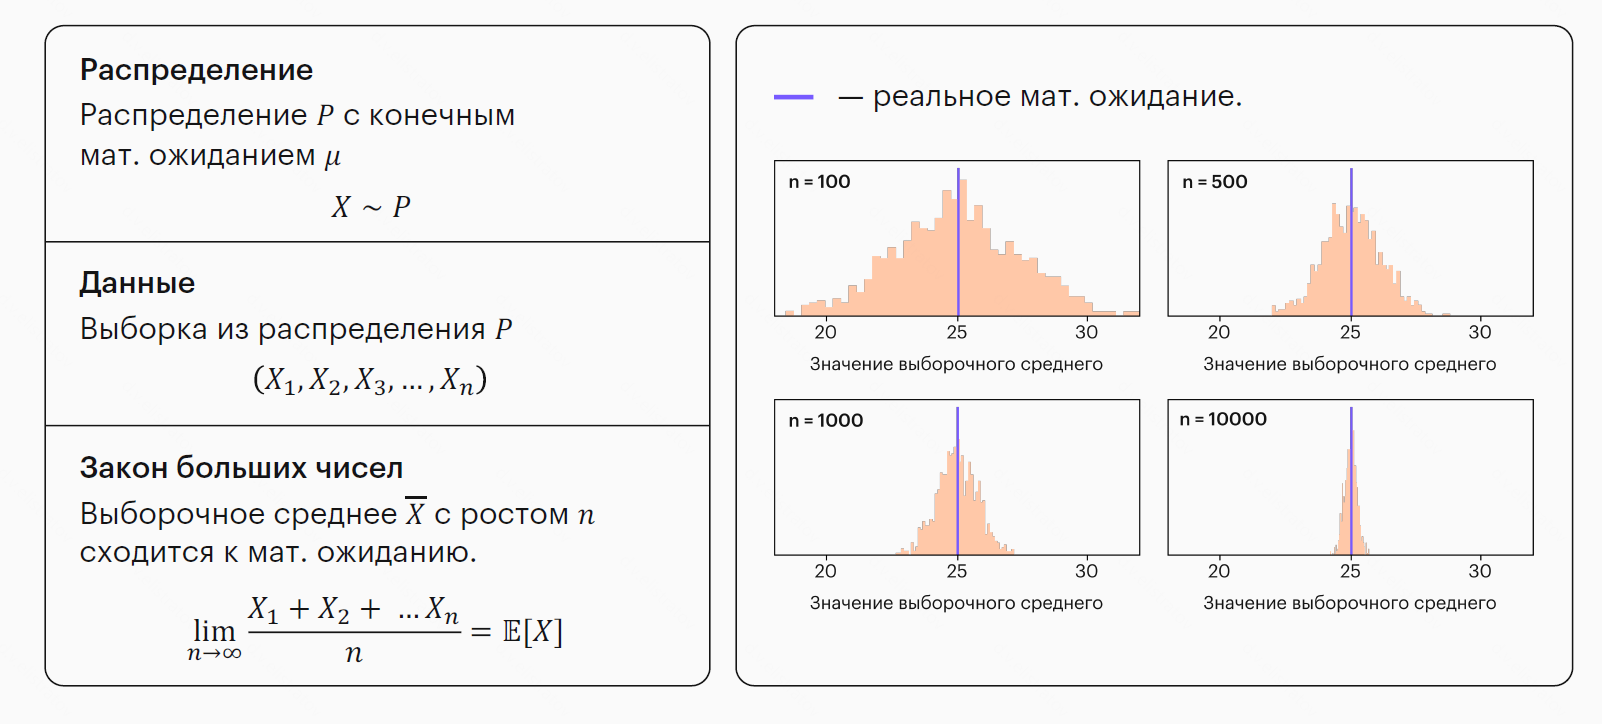

## Пример 1. Экспоненциальное распределение

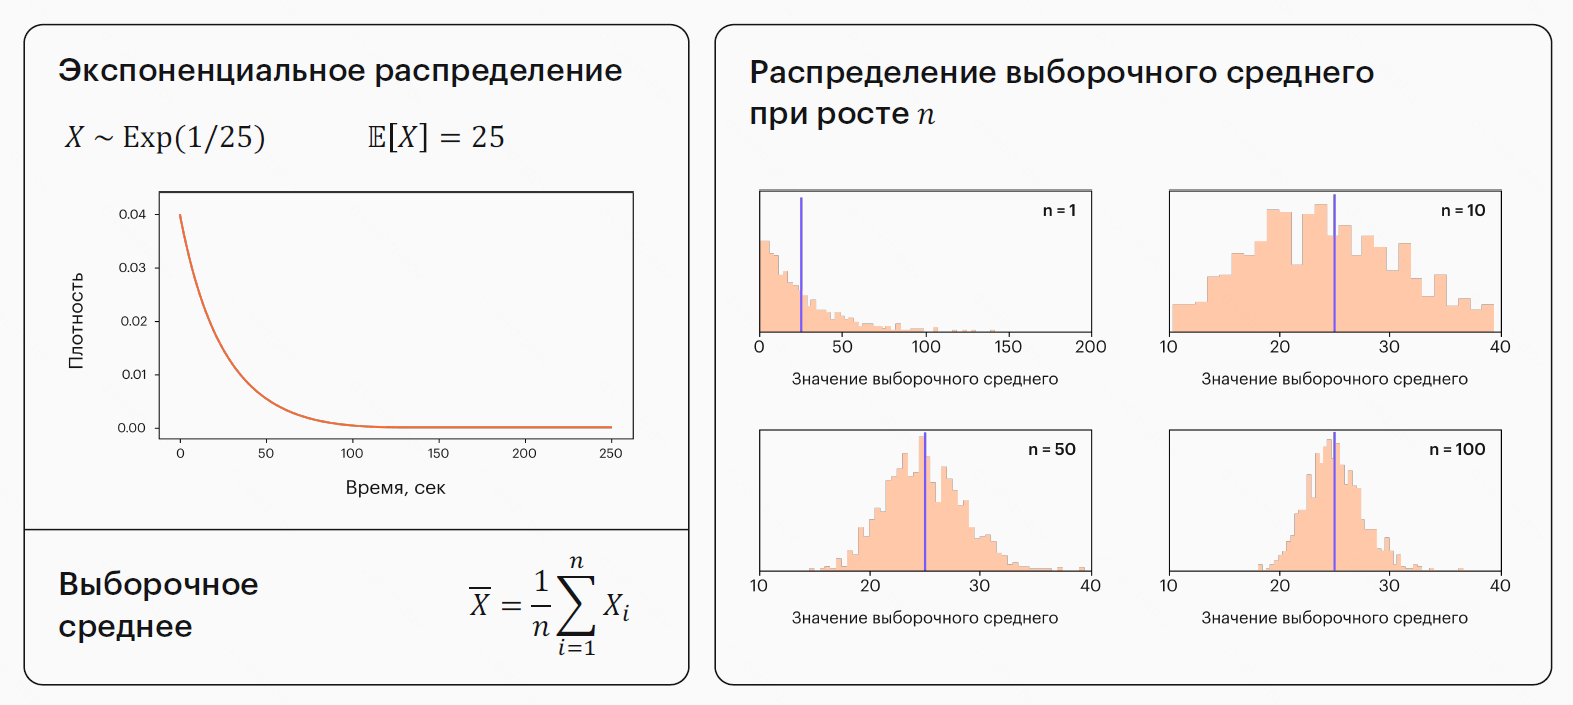

# Центрально-Предельная теорема

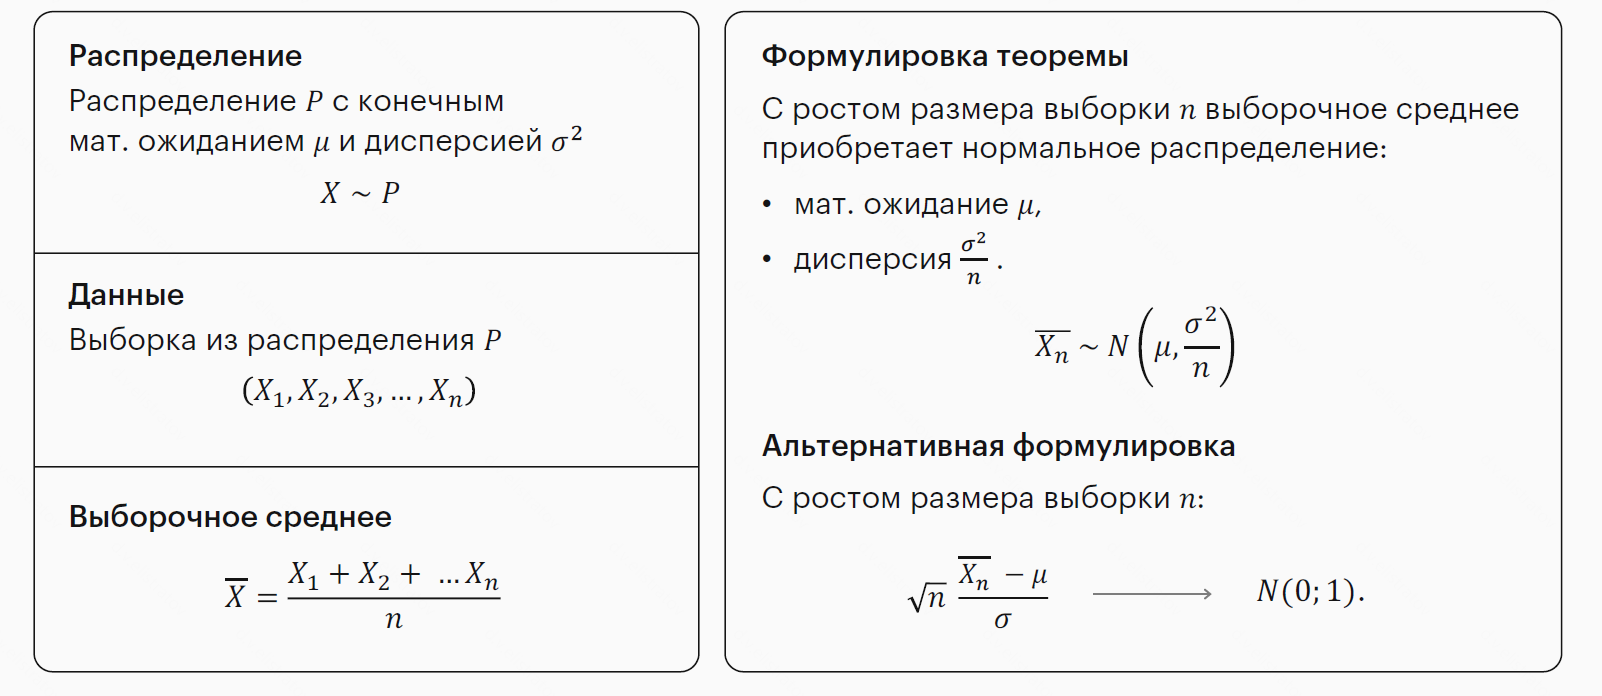

*Пусть есть распределение роста всех людей на планете.*

*Если взять очень много выборок людей и в каждой выборке рассчитать среднее, то мы увидим, как гистограмма средних будет всё ближе к нормальному распределению.*

## Пример. Демонстрация ЦПТ для логнормального распределения

In [ ]:
from scipy.stats import lognorm, norm

# Исходные параметры логнормального распределения
lgnrm_mu = 1.281      # среднее нормального распределения в лог-шкале
lgnrm_sigma = 1.06    # стандартное отклонение в лог-шкале

# Расчет теоретических моментов логнормального распределения
real_lognorm_mean = np.exp(lgnrm_mu + lgnrm_sigma**2 / 2)
real_lognorm_var = (np.exp(lgnrm_sigma**2) - 1) * np.exp(2 * lgnrm_mu + lgnrm_sigma**2)

print("Параметры логнормального распределения:")
print(f"  Мю (в лог-шкале): {lgnrm_mu}")
print(f"  Сигма (в лог-шкале): {lgnrm_sigma}")
print(f"  Теоретическое среднее: {real_lognorm_mean:.3f}")
print(f"  Теоретическая дисперсия: {real_lognorm_var:.3f}")

Параметры логнормального распределения:
  Мю (в лог-шкале): 1.281
  Сигма (в лог-шкале): 1.06
  Теоретическое среднее: 6.314
  Теоретическая дисперсия: 82.764


Создаем объект логнормального распределения

In [ ]:
lognorm_rv = lognorm(s=lgnrm_sigma, scale=np.exp(lgnrm_mu))

Теперь сгенерируем $N$ случайных величин по $M$ наблюдений и продемонстрируем, как среднее стремится к нормальному распределению.

In [ ]:
n = 10000      # Максимальное количество случайных величин для суммирования
n_obs = 10**5  # Количество наблюдений (размер выборки для гистограмм)

# Параметры нормального распределения для аппроксимации
# По ЦПТ: среднее выборочное ~ N(μ, σ²/n)
norm_mu = real_lognorm_mean
norm_std = np.sqrt(real_lognorm_var / n)

print(f"\nПараметры нормального приближения (n={n}):")
print(f"  Среднее: {norm_mu:.2f}")
print(f"  Стандартное отклонение: {norm_std:.3f}")
print(f"  Дисперсия: {norm_std**2:.3f}")


Параметры нормального приближения (n=10000):
  Среднее: 6.31
  Стандартное отклонение: 0.091
  Дисперсия: 0.008


In [ ]:
# Инициализация массива для накопления сумм
X_i = np.zeros(n_obs)

# Точки, в которых будем строить гистограммы
n_points_to_plot = (1, 10, 100, 500, 1000, n)

**Запуск симуляции**

In [ ]:
partial_sums = {}
current_sum = np.zeros(n_obs)

for i in range(1, n + 1):
    # Генерируем новые случайные величины на каждом шаге
    new_samples = lognorm_rv.rvs(n_obs)
    # Накопление сумм
    current_sum += new_samples

    # Сохраняем промежуточную сумму для нужных точек
    if i in n_points_to_plot:
        partial_sums[i] = current_sum.copy()  # Важно: сохраняем копию!

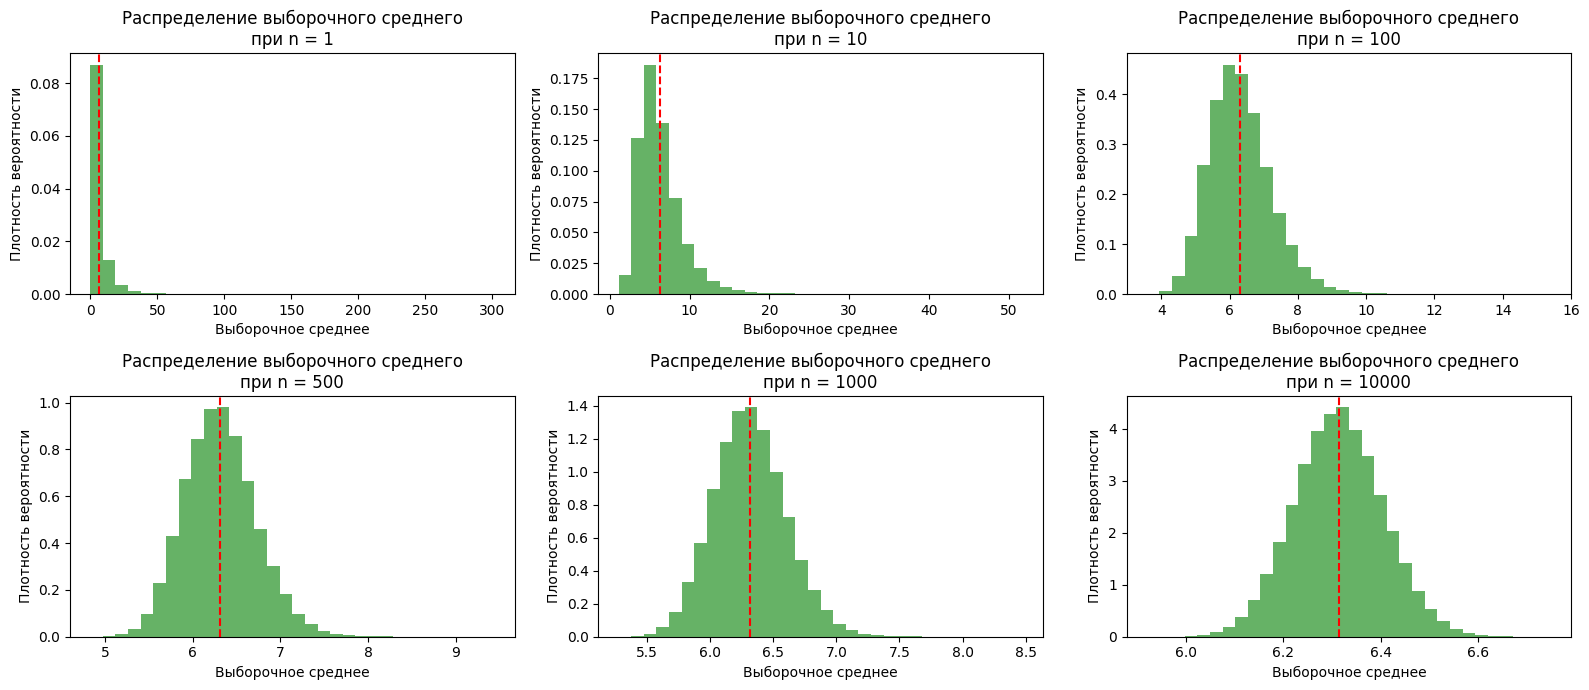

In [ ]:
plt.figure(figsize=(16, 7))

# Создаем подграфики для каждой точки визуализации
for idx, n_val in enumerate(n_points_to_plot, 1):
    plt.subplot(2, 3, idx)

    # Берем сохраненную промежуточную сумму и делим на n_val
    sample_means = partial_sums[n_val] / n_val

    # Строим гистограмму выборочных средних
    plt.hist(sample_means, bins=32, color='green', alpha=0.6,
             density=True, label=f'n = {n_val}')
    plt.axvline(real_lognorm_mean, color='red', linestyle='--')
    plt.title(f'Распределение выборочного среднего\nпри n = {n_val}')
    plt.xlabel('Выборочное среднее')
    plt.ylabel('Плотность вероятности')
plt.tight_layout()
plt.show()

**Вывод:**

Чем больше выборок, тем ближе выборочное среднее к нормальному распределению.


# Асимптотическая нормальность выборочного квантиля

Пусть $X_1,\ldots,X_n$ — независимые одинаково распределённые случайные величины с непрерывной функцией распределения $F$ и плотностью $f$.

Квантиль уровня $p$ генерального распределения определяется как

$$
q_p = F^{-1}(p).
$$

Обозначим через $\widehat q_p$ соответствующий выборочный квантиль.

Если плотность $f$ непрерывна и положительна в точке $q_p$, то

$$
\sqrt{n}\left(\widehat q_p-q_p\right)
\xrightarrow{d}
\mathcal{N}\left(
0,
\frac{p(1-p)}{f(q_p)^2}
\right).
$$

Эквивалентно,

$$
\frac{
\sqrt{n}\left(\widehat q_p-q_p\right)f(q_p)
}{
\sqrt{p(1-p)}
}
\xrightarrow{d}
\mathcal{N}(0,1).
$$

Следовательно, при достаточно большом размере выборки распределение выборочного квантиля приближённо нормально:

$$
\widehat q_p
\approx
\mathcal{N}\left(
q_p,
\frac{p(1-p)}{n f(q_p)^2}
\right).
$$

## Непрерывное равномерное распределение

Рассмотрим непрерывное равномерное распределение

$$
X_i \sim U(0,1).
$$

Для него

$$
F(x)=x,
\qquad
f(x)=1,
\qquad
0 \leq x \leq 1.
$$

Поэтому квантиль уровня $p$ равен

$$
q_p=p,
$$

а теорема принимает вид

$$
\sqrt{n}\left(\widehat q_p-p\right)
\xrightarrow{d}
\mathcal{N}\left(0,p(1-p)\right).
$$

После стандартизации получаем

$$
\frac{
\sqrt{n}\left(\widehat q_p-p\right)
}{
\sqrt{p(1-p)}
}
\xrightarrow{d}
\mathcal{N}(0,1).
$$

В ходе эксперимента необходимо рассмотреть три выборочных квантиля:

$$
p=0.25
$$

— первый квартиль,

$$
p=0.5
$$

— медиана,

$$
p=0.9
$$

— девятый дециль.

Для каждого квантиля нужно многократно сгенерировать выборки разных размеров, вычислить выборочный квантиль и сравнить распределение его стандартизованных значений с распределением $\mathcal{N}(0,1)$.

По мере роста $n$ гистограмма должна всё лучше приближаться к плотности стандартного нормального распределения.

**Продемонстрируем на симуляции**

In [ ]:
rng = np.random.default_rng(42)

n_repeats = 5000
sample_sizes = [3, 50, 10000]

In [ ]:
def plot_quantile_distribution(p, quantile_name):
    x_grid = np.linspace(-4, 4, 400)

    for n in sample_sizes:
        samples = rng.uniform(0, 1, size=(n_repeats, n))
        sample_quantiles = np.quantile(samples, p, axis=1)

        z = (
            np.sqrt(n)
            * (sample_quantiles - p)
            / np.sqrt(p * (1 - p))
        )

        plt.hist(
            z,
            bins=40,
            density=True,
            alpha=0.35,
            label=f"n = {n}"
        )

    plt.plot(
        x_grid,
        norm.pdf(x_grid),
        linewidth=2,
        label="N(0, 1)"
    )

    plt.xlabel("Стандартизованный выборочный квантиль")
    plt.ylabel("Плотность")
    plt.title(quantile_name)
    plt.legend()
    plt.show()

Распределение первого квартиля

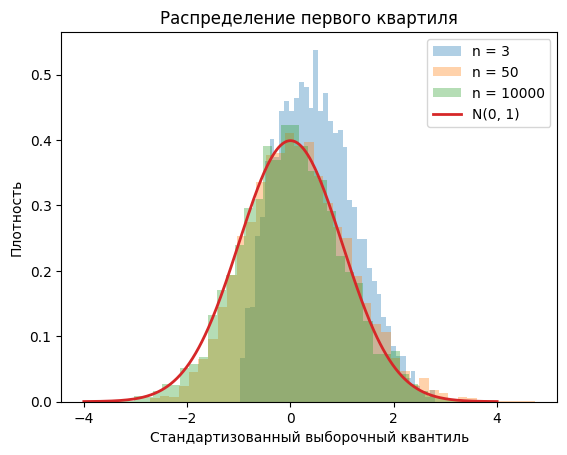

In [ ]:
plot_quantile_distribution(
    p=0.25,
    quantile_name="Распределение первого квартиля"
)

Распределение медианы

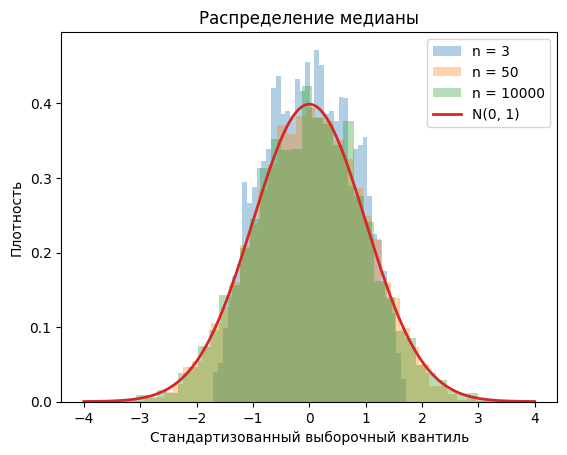

In [ ]:
plot_quantile_distribution(
    p=0.5,
    quantile_name="Распределение медианы"
)

Распределение девятого дециля

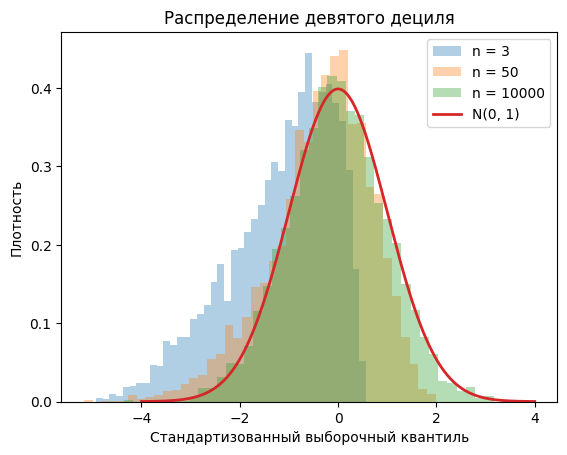

In [ ]:
plot_quantile_distribution(
    p=0.9,
    quantile_name="Распределение девятого дециля"
)

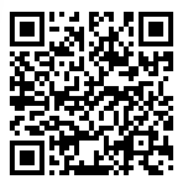